# WETH/USDT LP의 IL · LVR · Predictable Loss

이 노트북은 `non_same_block_pair_returns.parquet`의 10,795개 multi-block operation pair를 동일한 표본으로 사용한다. 핵심 공식과 event-order 계산은 `analysis/src/lp_risk`에 있으며, 노트북은 versioned output을 생성하고 표와 차트를 표시한다.

- 평가통화: USDT, 외부가격: event 직전 1초 Binance ETHUSDT
- pool 경로: `(block_number, transaction_index, log_index)` 순서의 exact `sqrt_price_x96`; 주 PL은 block-end mesh
- IL/LVR/PL: fee와 gas 제외
- risk-free rate: 동결된 FRED SOFR snapshot, ACT/360
- PL은 Predictable Loss이며 profit and loss가 아니다.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
from IPython.display import display

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

REPOSITORY_ROOT = Path(".").resolve()
sys.path.insert(0, str(REPOSITORY_ROOT / "data" / "src"))
sys.path.insert(0, str(REPOSITORY_ROOT / "analysis" / "src"))

from lp_risk.pipeline import build_risk_metrics
from uniswap_v3_data.paths import resolve_data_root

DATA_ROOT = resolve_data_root()
OUTPUT_ROOT = DATA_ROOT / "derived" / "risk_metrics" / "v2"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)


## 1. 재현 가능한 output 생성

노트북 실행 중에는 외부 네트워크를 사용하지 않는다. SOFR snapshot이 없다면 먼저 `python analysis/scripts/prepare_sofr.py`를 한 번 실행한다. 이후 실행은 입력 manifest와 고정된 snapshot만 읽는다.


In [2]:
artifacts = build_risk_metrics(
    DATA_ROOT, output_root=OUTPUT_ROOT, repository_root=REPOSITORY_ROOT
)
position_metrics = pd.read_parquet(artifacts.position_metrics)
portfolio_daily = pd.read_parquet(artifacts.portfolio_daily)
representatives = pd.read_parquet(artifacts.representative_positions)
representative_paths = pd.read_parquet(artifacts.representative_paths)
run_manifest = json.loads(artifacts.manifest.read_text())

display(pd.DataFrame({
    "item": ["positions", "strict sensitivity positions", "position-days", "representative path rows"],
    "count": [
        len(position_metrics),
        int(position_metrics["is_strict_pair"].sum()),
        int(portfolio_daily["position_day_count"].sum()),
        len(representative_paths),
    ],
}))
display(pd.DataFrame(run_manifest["artifacts"]))


loading exact pool Swap path and strict-prior Binance marks


loaded ordered Swap path 01/64 partitions


loaded ordered Swap path 12/64 partitions


loaded ordered Swap path 24/64 partitions


loaded ordered Swap path 36/64 partitions


...

calculated CEX QV sensitivity 60/64 partitions


calculated CEX QV sensitivity 64/64 partitions


writing versioned risk-metric artifacts


,item,count
0,positions,10795
1,strict sensitivity positions,10718
2,position-days,220389
3,representative path rows,339888


,path,rows,size_bytes,sha256
0,position_lifetime_metrics.parquet,10795,8794850,62f709a29d51ab3380e8279569d078e48c9f8dd6114287...
1,capital_weighted_position_daily.parquet,1932,339458,7117f3c8d38e2bfb571d44ce980b3ff5715c6abb29d28b...
2,representative_positions.parquet,4,13384,1920f2e064d81b11c0aaf98a775964ba9f895cf24b0340...
3,representative_position_paths.parquet,339888,44237642,2f3c37fcc972d5e1680675119ed77a8f31271f6f419cac...


## 2. 공식과 부호

$P_t$는 내부 pool 가격, $S_t$는 외부 Binance 가격, $x(P),y(P)$는 fee-exclusive inventory다. $V(P)=x(P)P+y(P)$, $W(P,S)=x(P)S+y(P)$, $H(S)=x_0S+y_0$로 둔다. 전체 정의와 유도는 `analysis/RISK_METRICS.md`에 고정한다.

### Impermanent Loss

$$IL_t^{signed}=\frac{V_t^{LP}-V_t^{HODL}}{V_t^{HODL}}.$$

Entry와 exit은 실제 Mint/Burn amount, 중간 경로는 exact pool sqrt-price에서 복원한 fee-exclusive inventory를 사용한다. 비교 차트에는 $L_t^{IL}=[H(S_t)-W(P_t,S_t)]/V_0$를 loss-positive 값으로 표시한다. 정확한 이산 dynamics는 $\Delta L_j^{IL}=x_0\Delta S_j-[W(P_j,S_j)-W(P_{j-1},S_{j-1})]$이며, 이 증분은 양·음 모두 가능하다.

### Loss-versus-Rebalancing

$$\Delta LVR_k=-\left(S_k\Delta x_k+\Delta y_k\right).$$

여기서 $S_k$는 Swap 직전 Binance 가격이다. 실증 LVR은 pool–CEX basis와 이산적 event timing 때문에 감소하거나 음수일 수 있어 clipping하지 않는다. CEX QV의 1초·5초·1분 근사는 sensitivity로만 둔다.

### Predictable Loss

보유 중 Swap이 있는 block을 $b=1,\ldots,B$로 두고, $\bar P_0$는 entry 직전 상태, $\bar P_b$는 block $b$의 마지막 in-scope Swap 후 상태로 둔다. 주지표는

$$C_b=V(\bar P_{b-1})+x(\bar P_{b-1})(\bar P_b-\bar P_{b-1})-V(\bar P_b),$$
$$D_b=G(t_{b-1},t_b)D_{b-1}+C_b.$$

논문 용어를 따라 **PL = Convexity Cost + Opportunity Cost**로 명명한다. `pl_convexity_cost`는 $\sum C_b$, `pl_opportunity_cost`는 $D_T-\sum C_b$, 논문 부호의 PL은 $-D_T$다. 모든 Swap 상태를 쓰는 이전 방식은 `pl_swap_event_*` sensitivity로만 보존한다. SOFR는 전체 WETH inventory가 아니라 이미 발생한 replication gap에만 적용된다. 따라서 Convexity Cost가 전혀 없으면 $r>0$이어도 PL은 0이다.

### 연속시간 dynamics (이상적 $P=S$ limit)

$$dV_t^{LP}=x(S_t)dS_t+\frac12V''(S_t)d[S]_t,$$
$$dL_t^{IL}=(x_0-x(S_t))dS_t-\frac12V''(S_t)d[S]_t,$$
$$dLVR_t=dC_t=-\frac12V''(S_t)d[S]_t,$$
$$dD_t=dC_t+r_tD_tdt,\qquad dO_t=r_tD_tdt.$$

따라서 $dL^{IL}=(x_0-x)dS+dLVR$이고, $r=0$의 이상적 limit에서는 $dPL_{loss}=dLVR=dC$다. 실제 $P\ne S$ 데이터에서는 이 식을 직접 강제하지 않고 위의 exact discrete increments를 누적한다.


In [3]:
distribution_columns = [
    "holding_seconds",
    "il_loss_on_initial",
    "lvr_rebalancing_on_initial",
    "lvr_qv_1s_on_initial",
    "lvr_qv_5s_on_initial",
    "lvr_qv_1m_on_initial",
    "pl_convexity_cost_on_initial",
    "pl_opportunity_cost_on_initial",
    "pl_loss_on_initial",
    "pl_swap_event_loss_on_initial",
]
display(position_metrics[distribution_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
holding_seconds,10795.0,1.676982e+06,7.502471e+06,12.000000,9.600000e+01,608.4,2.788800e+04,1.608240e+05,733842.000000,6.812484e+06,2.806144e+07,1.586891e+08
il_loss_on_initial,10795.0,2.280211e-02,6.225784e-02,-0.011237,-2.074195e-08,0.0,3.892074e-06,3.332478e-03,0.019629,1.056493e-01,2.797377e-01,1.620519e+00
lvr_rebalancing_on_initial,10795.0,1.619309e-02,4.194464e-02,-0.011237,-0.000000e+00,-0.0,8.176867e-04,4.735877e-03,0.015464,6.736803e-02,1.536479e-01,1.143665e+00
lvr_qv_1s_on_initial,10795.0,1.511836e-02,4.231231e-02,0.000000,0.000000e+00,0.0,6.710524e-04,4.393570e-03,0.014282,6.068426e-02,1.530266e-01,1.164683e+00
lvr_qv_5s_on_initial,10795.0,1.750022e-02,4.736764e-02,0.000000,0.000000e+00,0.0,8.308058e-04,5.301421e-03,0.016707,7.069500e-02,1.698094e-01,1.315546e+00
lvr_qv_1m_on_initial,10795.0,1.937324e-02,5.214569e-02,0.000000,0.000000e+00,0.0,9.068197e-04,5.933093e-03,0.018715,7.881987e-02,1.819297e-01,1.458977e+00
pl_convexity_cost_on_initial,10795.0,1.674553e-02,5.590684e-02,0.000000,0.000000e+00,0.0,5.460469e-04,4.215603e-03,0.014165,6.386345e-02,1.819524e-01,1.410788e+00
pl_opportunity_cost_on_initial,10795.0,2.515902e-04,4.295543e-03,0.000000,0.000000e+00,0.0,3.913549e-09,2.170054e-07,0.000004,1.950576e-04,2.399681e-03,1.824558e-01
pl_loss_on_initial,10795.0,1.699712e-02,5.918809e-02,0.000000,0.000000e+00,0.0,5.460610e-04,4.218615e-03,0.014171,6.413503e-02,1.820790e-01,1.560080e+00
pl_swap_event_loss_on_initial,10795.0,1.952935e-01,1.409161e+00,0.000000,0.000000e+00,0.0,9.342392e-04,1.073404e-02,0.059550,5.680903e-01,3.183629e+00,5.316118e+01


## 3. Capital-weighted multi-block operation-pair risk metrics

각 날짜와 half-open lifetime이 겹치는 position을 `min(exit, UTC day-end)`에서 평가하고, dollar loss 합계를 initial capital 합계로 나눈 사후 position-day 대표값이다. 표본 진입·청산에 따라 선이 점프할 수 있으며 실시간 투자 portfolio가 아니다.


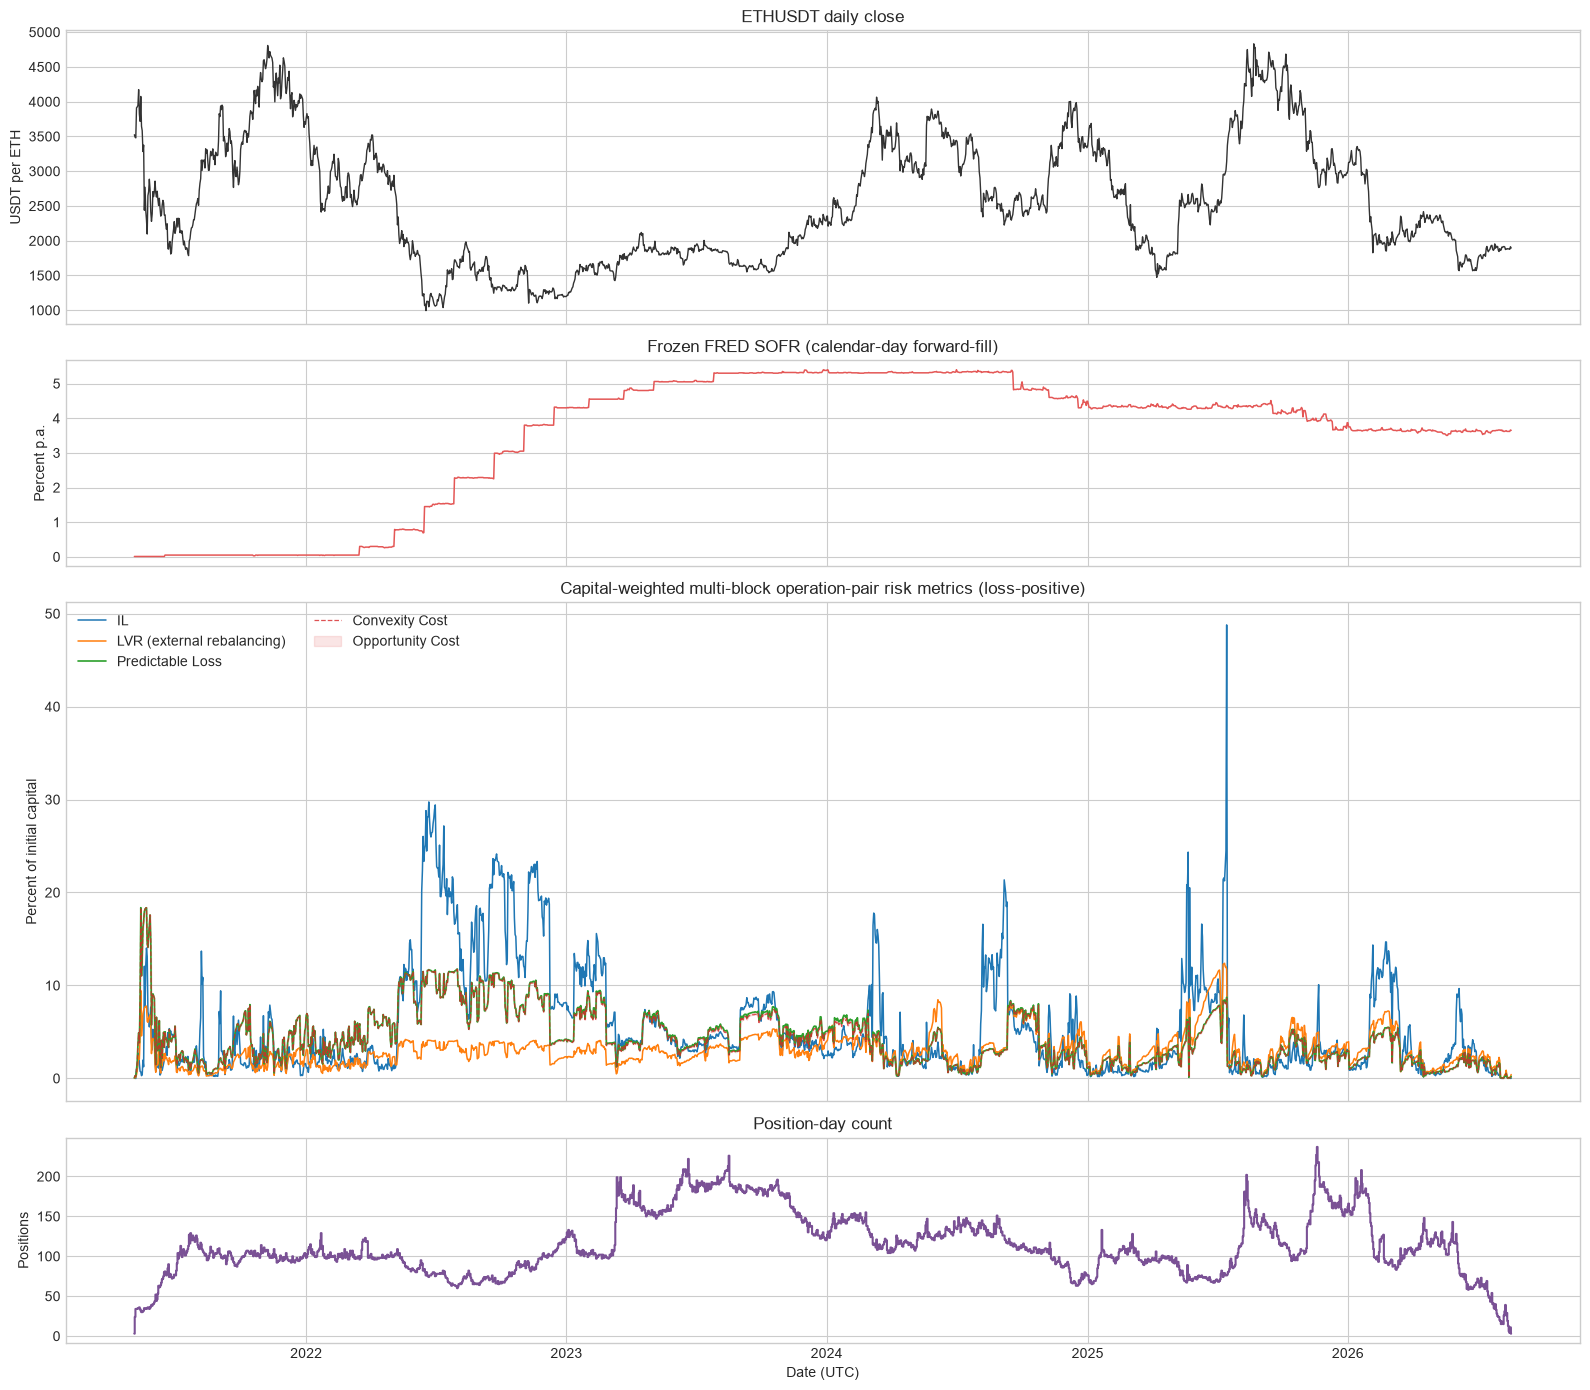

In [4]:
daily = portfolio_daily.sort_values("date")
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True,
                         gridspec_kw={"height_ratios": [1.0, 0.7, 1.7, 0.7]})
axes[0].plot(daily["date"], daily["ethusdt_close"], color="#333333", linewidth=1.0)
axes[0].set(title="ETHUSDT daily close", ylabel="USDT per ETH")
axes[1].plot(daily["date"], daily["sofr_percent"], color="#E45756", linewidth=1.1)
axes[1].set(title="Frozen FRED SOFR (calendar-day forward-fill)", ylabel="Percent p.a.")
axes[2].plot(daily["date"], daily["capital_weighted_il_loss_pct"], label="IL", linewidth=1.1)
axes[2].plot(daily["date"], daily["capital_weighted_lvr_loss_pct"], label="LVR (external rebalancing)", linewidth=1.1)
axes[2].plot(daily["date"], daily["capital_weighted_pl_loss_pct"], label="Predictable Loss", linewidth=1.2)
axes[2].plot(daily["date"], daily["capital_weighted_pl_convexity_cost_pct"], label="Convexity Cost", linestyle="--", linewidth=0.9, alpha=0.8)
axes[2].fill_between(daily["date"], daily["capital_weighted_pl_convexity_cost_pct"], daily["capital_weighted_pl_loss_pct"], color="#E45756", alpha=0.15, label="Opportunity Cost")
axes[2].set(title="Capital-weighted multi-block operation-pair risk metrics (loss-positive)", ylabel="Percent of initial capital")
axes[2].legend(loc="best", ncol=2)
axes[3].step(daily["date"], daily["position_day_count"], where="mid", color="#7A5195")
axes[3].set(title="Position-day count", ylabel="Positions", xlabel="Date (UTC)")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "capital_weighted_risk_metrics.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. 사후 시장방향 × lifetime 대표 position

상승·하락은 각 position 보유기간 ETH log return의 상·하위 25%, short·long은 전체 holding time의 하·상위 25%다. 각 교집합에서 initial capital, range width, lifetime, ETH return의 robust medoid를 고른다. 이 분류는 미래 exit 가격을 쓰는 설명용 사례이며 confirmatory regime 변수가 아니다.


In [5]:
representative_table = representatives.copy()
representative_table["holding_days"] = representative_table["holding_seconds"] / 86_400
representative_table["eth_return_pct"] = 100 * np.expm1(representative_table["eth_log_return"])
display(representative_table[[
    "market_regime", "lifetime_bucket", "candidate_count", "operation_id",
    "entry_timestamp", "exit_timestamp", "holding_days", "eth_return_pct",
    "initial_wealth_usdt", "tick_lower", "tick_upper", "is_strict_pair",
]])


,market_regime,lifetime_bucket,candidate_count,operation_id,entry_timestamp,exit_timestamp,holding_days,eth_return_pct,initial_wealth_usdt,tick_lower,tick_upper,is_strict_pair
0,bull,short,63,be54851eff87afe564b42729c5128af613662647d4597c...,2024-08-08 12:30:59+00:00,2024-08-08 17:12:47+00:00,0.195694,4.424211,39904.804428,-198470,-197690,True
1,bull,long,1161,05345cb10258b7f2eb935b0f328c253c175de7db6a9bc4...,2023-12-17 14:12:11+00:00,2024-01-12 01:05:35+00:00,25.453750,17.124761,10640.019609,-200610,-198080,True
2,bear,short,100,02ab86f1afe5b84ba68eb5dd039d106c24d3985b7e003d...,2024-01-12 17:18:47+00:00,2024-01-12 22:05:35+00:00,0.199167,-3.908297,44140.598106,-198100,-197310,True
3,bear,long,1193,9fa31bad04448caea02948722f424804d20e3ddc0cf514...,2025-03-12 23:15:59+00:00,2025-04-08 11:44:23+00:00,26.519722,-16.915919,4306.285445,-201290,-199130,True


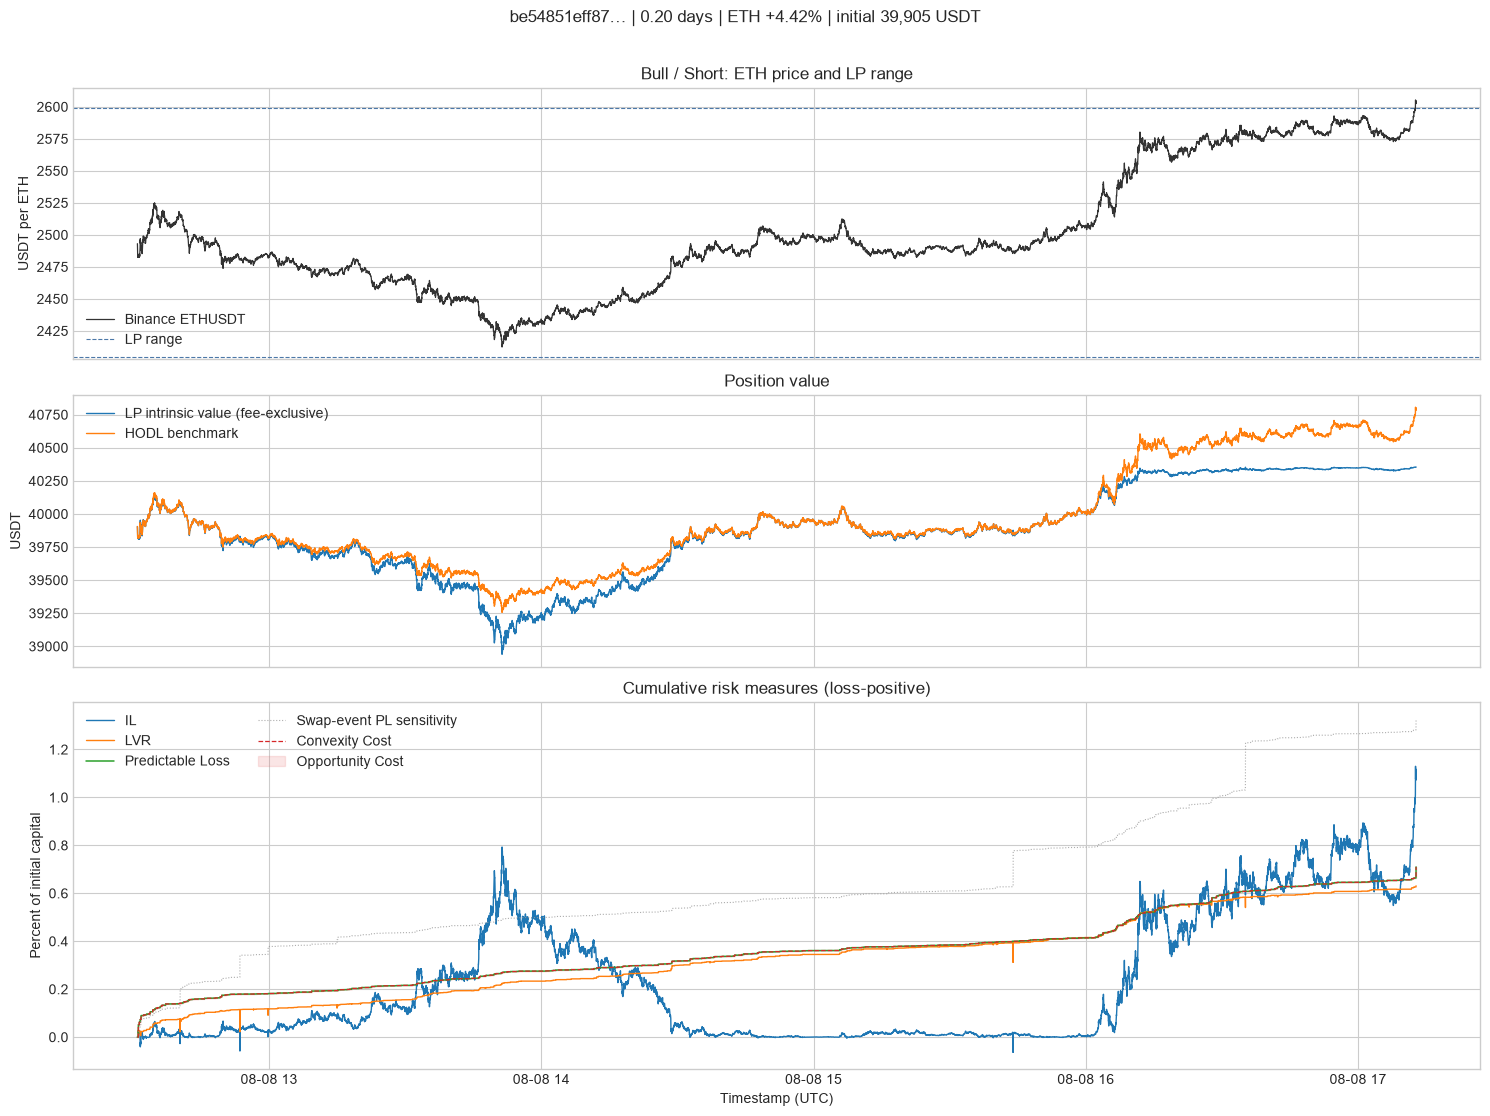

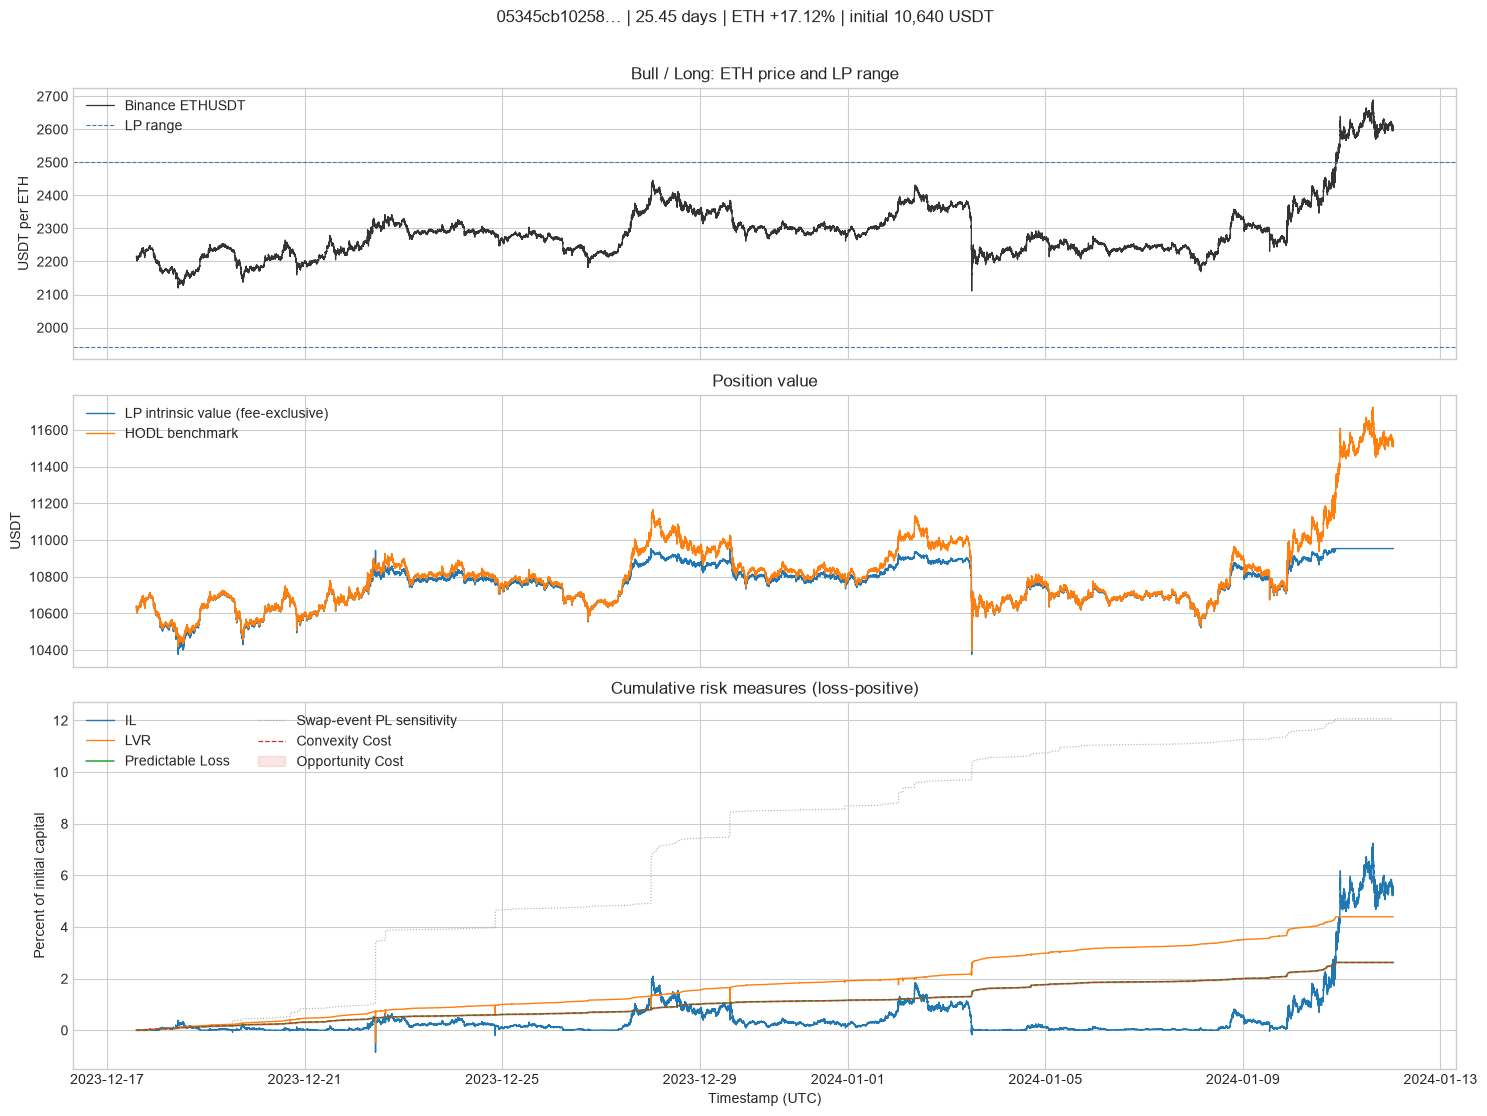

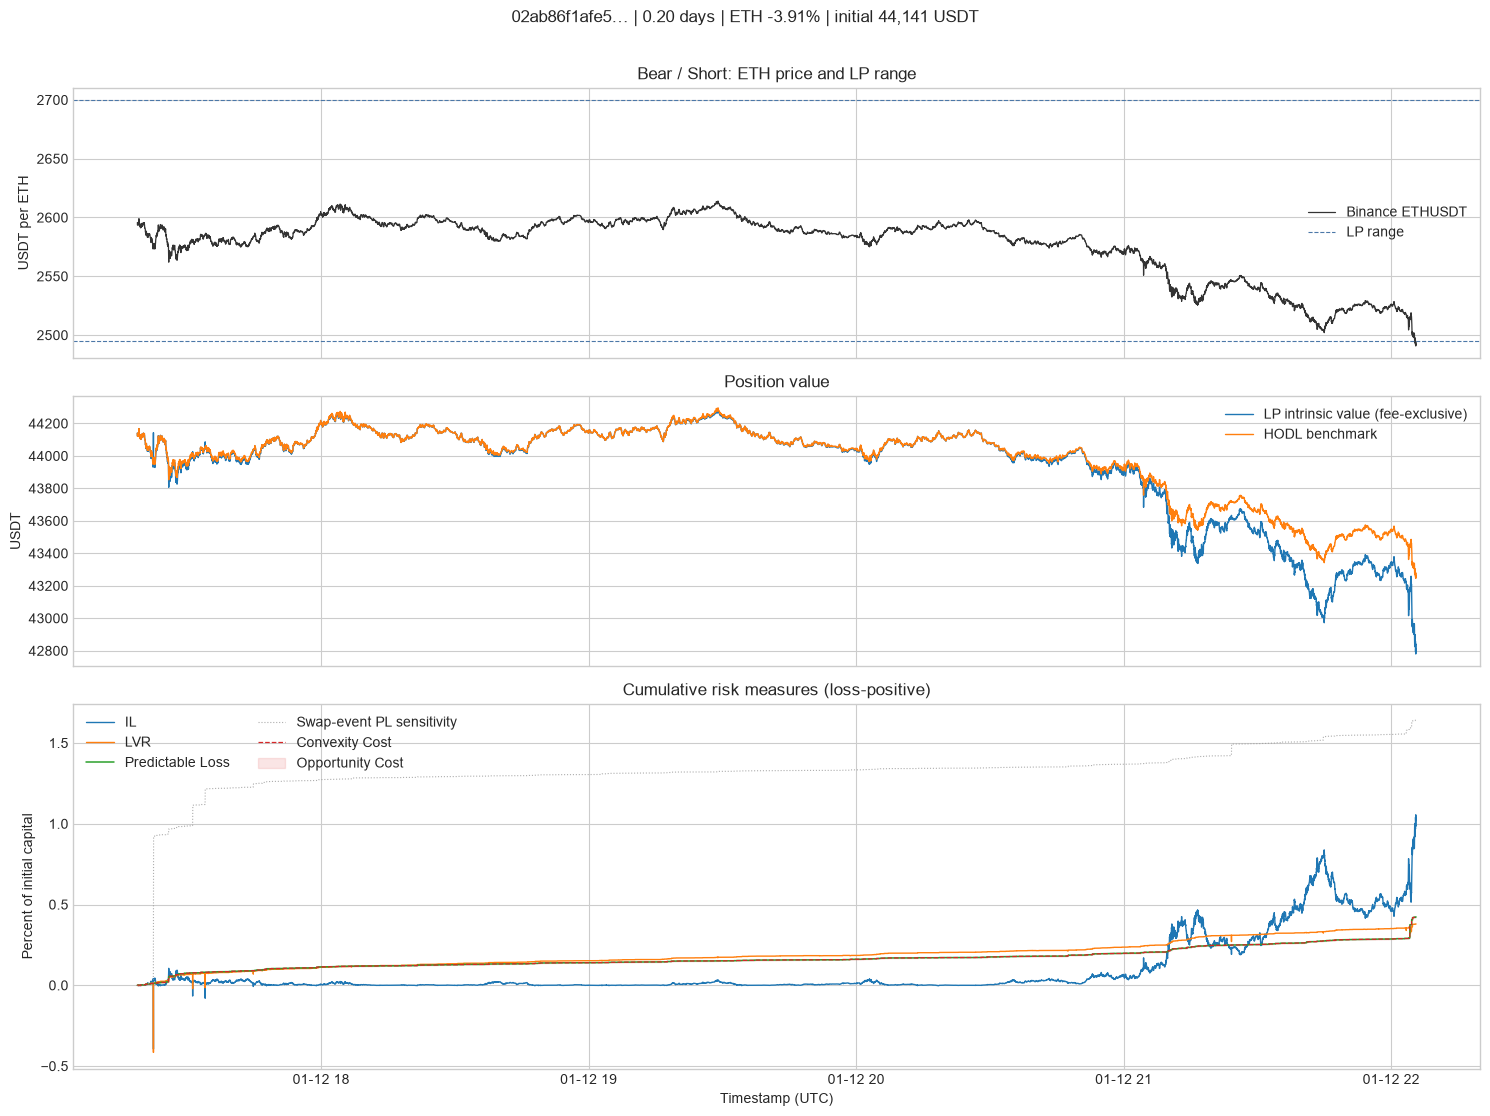

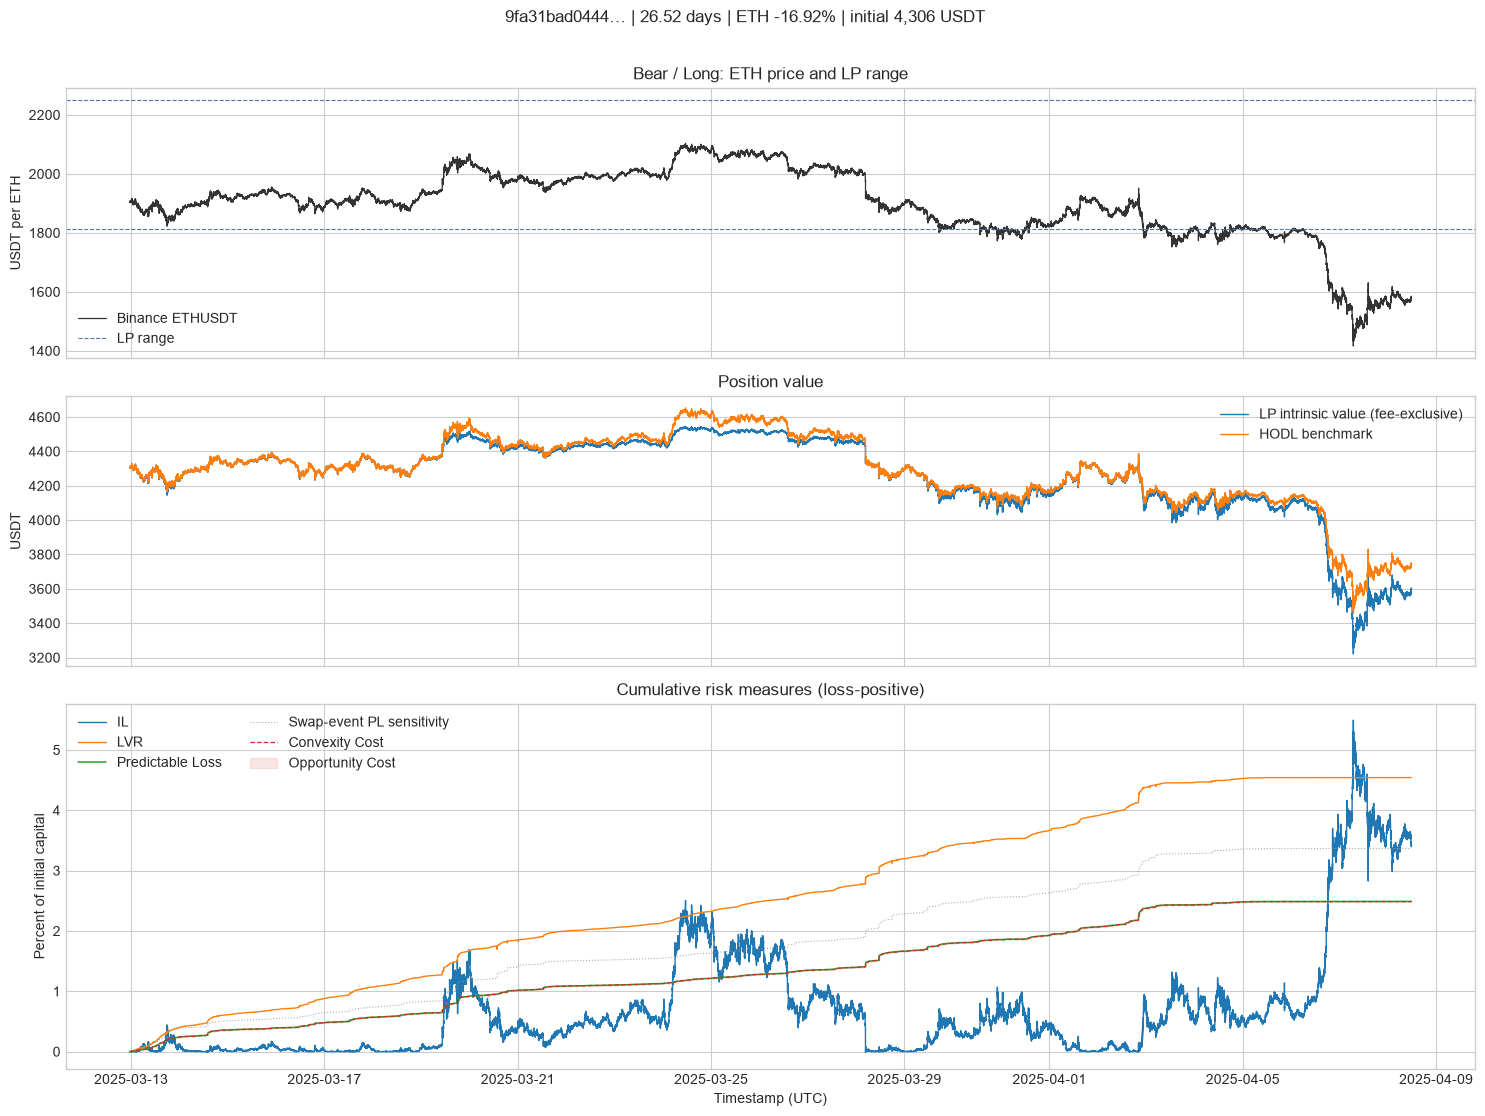

In [6]:
def plot_representative_position(metadata, path):
    kind_rank = path["row_kind"].map({"entry": 0, "swap": 1, "grid": 2, "exit": 3})
    path = path.assign(_kind_rank=kind_rank).sort_values(["timestamp", "_kind_rank", "block_number", "transaction_index", "log_index"], kind="stable", na_position="last").drop(columns="_kind_rank")
    holding_days = float(metadata["holding_seconds"]) / 86_400
    eth_return = 100 * np.expm1(float(metadata["eth_log_return"]))
    initial_capital = float(metadata["initial_wealth_usdt"])
    label = f"{metadata['market_regime'].title()} / {metadata['lifetime_bucket'].title()}"
    fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True, gridspec_kw={"height_ratios": [1.0, 1.0, 1.35]})
    axes[0].plot(path["timestamp"], path["external_ethusdt"], color="#333333", linewidth=0.9, label="Binance ETHUSDT")
    axes[0].axhline(path["range_lower_usdt"].iloc[0], color="#4C78A8", linestyle="--", linewidth=0.8, label="LP range")
    axes[0].axhline(path["range_upper_usdt"].iloc[0], color="#4C78A8", linestyle="--", linewidth=0.8)
    axes[0].set(title=f"{label}: ETH price and LP range", ylabel="USDT per ETH")
    axes[0].legend(loc="best")
    axes[1].plot(path["timestamp"], path["lp_intrinsic_value_usdt"], label="LP intrinsic value (fee-exclusive)", linewidth=1.0)
    axes[1].plot(path["timestamp"], path["hodl_value_usdt"], label="HODL benchmark", linewidth=1.0)
    axes[1].set(title="Position value", ylabel="USDT")
    axes[1].legend(loc="best")
    axes[2].plot(path["timestamp"], 100 * path["il_loss_on_initial"], label="IL", linewidth=1.0)
    axes[2].plot(path["timestamp"], 100 * path["lvr_rebalancing_on_initial"], label="LVR", linewidth=1.0)
    axes[2].plot(path["timestamp"], 100 * path["pl_loss_on_initial"], label="Predictable Loss", linewidth=1.1)
    axes[2].plot(path["timestamp"], 100 * path["pl_swap_event_loss_on_initial"], label="Swap-event PL sensitivity", color="#999999", linestyle=":", linewidth=0.8, alpha=0.8)
    axes[2].plot(path["timestamp"], 100 * path["pl_convexity_cost_usdt"] / initial_capital, label="Convexity Cost", linestyle="--", linewidth=0.9)
    axes[2].fill_between(path["timestamp"], 100 * path["pl_convexity_cost_usdt"] / initial_capital, 100 * path["pl_loss_on_initial"], color="#E45756", alpha=0.15, label="Opportunity Cost")
    axes[2].set(title="Cumulative risk measures (loss-positive)", ylabel="Percent of initial capital", xlabel="Timestamp (UTC)")
    axes[2].legend(loc="best", ncol=2)
    fig.suptitle(f"{metadata['operation_id'][:12]}… | {holding_days:.2f} days | ETH {eth_return:+.2f}% | initial {initial_capital:,.0f} USDT", y=1.01)
    fig.tight_layout()
    filename = f"representative_{metadata['market_regime']}_{metadata['lifetime_bucket']}.png"
    fig.savefig(FIGURE_ROOT / filename, dpi=180, bbox_inches="tight")
    plt.show()

for _, metadata in representatives.iterrows():
    path = representative_paths.loc[representative_paths["operation_id"] == metadata["operation_id"]].copy()
    plot_representative_position(metadata, path)


## 5. 해석 시 주의점

- `lvr_rebalancing`은 외부 Binance 가격에서 같은 inventory를 self-financing으로 조정하는 benchmark다. pool–CEX basis 때문에 실증 경로가 항상 단조증가하지는 않는다.
- 주 Convexity Cost는 block별 마지막 in-scope pool 상태를 잇는다. 한 block 안의 급락·복귀를 별도의 hedge 가능한 가격변화로 중복 계상하지 않는다.
- 모든 Swap을 쓰는 `pl_swap_event_*`는 microstructure/mesh sensitivity다. transient intra-block excursion 때문에 주 PL보다 크게 spike할 수 있다.
- SOFR opportunity component는 이미 발생한 PL gap의 이자이며 전체 LP principal 또는 WETH inventory의 대체수익이 아니다.
- QV LVR와 `expected_pl_r0_30d`는 강한 연속시간·가격일치·변동성 가정이 필요한 robustness 지표다.
- 대표 position의 bull/bear label은 exit까지의 가격을 사용한 사후 설명용 구분이다.


## 6. 월별 실제 총수익률 추적 실험

각 달에 청산된 position을 하나의 exit cohort로 묶고, initial capital 가중 실제 LP 총수익률을 IL·LVR·PL이 각각 얼마나 잘 따라가는지 비교한다. 실제 총수익률은 observed realized fee를 포함한 `lp_total_return_realized_fee`이며 gas는 포함하지 않는다.

- 전체: 10,795개 return-comparable multi-block position
- Bull: 각 position 보유기간 ETH log return의 상위 25%
- Bear: 각 position 보유기간 ETH log return의 하위 25%
- 중간 50%: 전체에는 포함하고 Bull/Bear panel에서는 제외
- 시간 단위: 청산 월, 값은 그 달에 청산된 position의 initial-capital-weighted mean

IL·LVR·PL은 loss-positive이므로 월별 시계열에서는 음수로 바꿔 실제 return 방향과 맞춘다. 각 지표의 단순 OLS fitted return을 실제 총수익률과 같은 축에 표시하고, R²와 RMSE는 노트북 출력에서만 비교한다. Bull/Bear는 달력상 시장국면이 아니라 exit까지의 가격을 사용한 사후 position label이다.


In [7]:
RISK_COLUMNS = {
    'IL': 'il_loss_on_initial',
    'LVR': 'lvr_rebalancing_on_initial',
    'PL': 'pl_loss_on_initial',
}
REQUIRED_EXPERIMENT_COLUMNS = [
    'operation_id',
    'entry_timestamp',
    'exit_timestamp',
    'initial_wealth_usdt',
    'token0_price_usdt_entry',
    'token0_price_usdt_exit',
    'lp_total_return_realized_fee',
    *RISK_COLUMNS.values(),
]
missing_columns = set(REQUIRED_EXPERIMENT_COLUMNS).difference(position_metrics.columns)
if missing_columns:
    raise ValueError(f'missing experiment columns: {sorted(missing_columns)}')

experiment_positions = position_metrics[REQUIRED_EXPERIMENT_COLUMNS].copy()
experiment_positions['entry_timestamp'] = pd.to_datetime(
    experiment_positions['entry_timestamp'], utc=True
)
experiment_positions['exit_timestamp'] = pd.to_datetime(
    experiment_positions['exit_timestamp'], utc=True
)
numeric_columns = [
    'initial_wealth_usdt',
    'token0_price_usdt_entry',
    'token0_price_usdt_exit',
    'lp_total_return_realized_fee',
    *RISK_COLUMNS.values(),
]
for column in numeric_columns:
    experiment_positions[column] = pd.to_numeric(experiment_positions[column])
numeric_values = experiment_positions[numeric_columns].to_numpy(dtype=np.float64)
if not np.isfinite(numeric_values).all():
    raise ValueError('experiment input contains null or non-finite numeric values')
if (experiment_positions['initial_wealth_usdt'] <= 0).any():
    raise ValueError('initial wealth must be positive')

experiment_positions['eth_log_return'] = np.log(
    experiment_positions['token0_price_usdt_exit']
    / experiment_positions['token0_price_usdt_entry']
)
eth_return_q25, eth_return_q75 = experiment_positions['eth_log_return'].quantile(
    [0.25, 0.75]
)
experiment_positions['market_group'] = np.select(
    [
        experiment_positions['eth_log_return'] <= eth_return_q25,
        experiment_positions['eth_log_return'] >= eth_return_q75,
    ],
    ['Bear', 'Bull'],
    default='Middle',
)
exit_index = pd.DatetimeIndex(experiment_positions['exit_timestamp'])
experiment_positions['exit_month'] = pd.to_datetime(
    exit_index.strftime('%Y-%m-01'), utc=True
)

sample_summary = pd.DataFrame(
    [
        {'sample': 'All', 'positions': len(experiment_positions)},
        {
            'sample': 'Bull',
            'positions': int(experiment_positions['market_group'].eq('Bull').sum()),
        },
        {
            'sample': 'Bear',
            'positions': int(experiment_positions['market_group'].eq('Bear').sum()),
        },
    ]
)
threshold_summary = pd.DataFrame(
    {
        'threshold': ['Bear upper bound (Q25)', 'Bull lower bound (Q75)'],
        'eth_log_return': [eth_return_q25, eth_return_q75],
        'eth_simple_return_pct': [
            100 * np.expm1(eth_return_q25),
            100 * np.expm1(eth_return_q75),
        ],
    }
)
display(sample_summary)
display(threshold_summary)


,sample,positions
0,All,10795
1,Bull,2699
2,Bear,2699


,threshold,eth_log_return,eth_simple_return_pct
0,Bear upper bound (Q25),-0.031147,-3.066706
1,Bull lower bound (Q75),0.035599,3.624044


In [8]:
MONTHLY_RISK_COLUMNS = {
    'IL': 'il_signed_pct',
    'LVR': 'lvr_signed_pct',
    'PL': 'pl_signed_pct',
}
all_exit_months = pd.date_range(
    experiment_positions['exit_month'].min(),
    experiment_positions['exit_month'].max(),
    freq='MS',
)

def build_monthly_exit_cohort(data, sample):
    if sample == 'All':
        subset = data.copy()
    else:
        subset = data.loc[data['market_group'].eq(sample)].copy()
    subset['actual_pnl_usdt'] = (
        subset['initial_wealth_usdt'] * subset['lp_total_return_realized_fee']
    )
    aggregations = {
        'position_count': ('operation_id', 'size'),
        'initial_capital_usdt': ('initial_wealth_usdt', 'sum'),
        'actual_pnl_usdt': ('actual_pnl_usdt', 'sum'),
    }
    for label, source in RISK_COLUMNS.items():
        numerator = f'{label.lower()}_signed_usdt'
        subset[numerator] = -subset['initial_wealth_usdt'] * subset[source]
        aggregations[numerator] = (numerator, 'sum')
    monthly = subset.groupby('exit_month', sort=True).agg(**aggregations)
    monthly['actual_return_pct'] = (
        100 * monthly['actual_pnl_usdt'] / monthly['initial_capital_usdt']
    )
    for label, target in MONTHLY_RISK_COLUMNS.items():
        monthly[target] = (
            100
            * monthly[f'{label.lower()}_signed_usdt']
            / monthly['initial_capital_usdt']
        )
    monthly = monthly.reindex(all_exit_months)
    monthly.index.name = 'exit_month'
    monthly['position_count'] = monthly['position_count'].fillna(0).astype(np.int64)
    monthly['sample'] = sample
    return monthly.reset_index()

monthly_tracking = pd.concat(
    [
        build_monthly_exit_cohort(experiment_positions, sample)
        for sample in ('All', 'Bull', 'Bear')
    ],
    ignore_index=True,
)
display(
    monthly_tracking.groupby('sample', sort=False).agg(
        calendar_months=('exit_month', 'size'),
        months_with_exits=('position_count', lambda values: int((values > 0).sum())),
        positions=('position_count', 'sum'),
    )
)


,calendar_months,months_with_exits,positions
sample,,,
All,64,64,10795
Bull,64,64,2699
Bear,64,64,2699


In [9]:
def fit_simple_tracking_model(frame, source):
    valid = frame[['actual_return_pct', source]].dropna()
    if len(valid) < 3:
        raise ValueError(f'not enough monthly observations for {source}')
    x = valid[source].to_numpy(dtype=np.float64)
    y = valid['actual_return_pct'].to_numpy(dtype=np.float64)
    design = np.column_stack([np.ones(len(valid)), x])
    intercept, slope = np.linalg.lstsq(design, y, rcond=None)[0]
    fitted = intercept + slope * x
    residual = y - fitted
    residual_sum_squares = float(np.square(residual).sum())
    total_sum_squares = float(np.square(y - y.mean()).sum())
    r_squared = 1.0 - residual_sum_squares / total_sum_squares
    rmse = float(np.sqrt(np.mean(np.square(residual))))
    return valid.index, fitted, intercept, slope, r_squared, rmse

tracking_parts = []
tracking_score_rows = []
for sample in ('All', 'Bull', 'Bear'):
    part = monthly_tracking.loc[monthly_tracking['sample'].eq(sample)].copy()
    for label, source in MONTHLY_RISK_COLUMNS.items():
        valid_index, fitted, intercept, slope, r_squared, rmse = (
            fit_simple_tracking_model(part, source)
        )
        fitted_column = f'{label.lower()}_fitted_return_pct'
        part[fitted_column] = np.nan
        part.loc[valid_index, fitted_column] = fitted
        tracking_score_rows.append(
            {
                'sample': sample,
                'metric': label,
                'months': len(valid_index),
                'intercept': intercept,
                'slope': slope,
                'r_squared': r_squared,
                'rmse_pct_points': rmse,
            }
        )
    tracking_parts.append(part)

monthly_tracking_fitted = pd.concat(tracking_parts, ignore_index=True)
tracking_scores = pd.DataFrame(tracking_score_rows)
best_index = tracking_scores.groupby('sample', sort=False)['r_squared'].idxmax()
tracking_scores['best_tracker'] = False
tracking_scores.loc[best_index, 'best_tracker'] = True
display(
    tracking_scores[
        ['sample', 'metric', 'months', 'r_squared', 'rmse_pct_points', 'best_tracker']
    ].round({'r_squared': 4, 'rmse_pct_points': 4})
)


,sample,metric,months,r_squared,rmse_pct_points,best_tracker
0,All,IL,64,0.3340,3.0823,True
1,All,LVR,64,0.0423,3.6962,False
2,All,PL,64,0.0460,3.6890,False
3,Bull,IL,64,0.4031,2.3076,True
4,Bull,LVR,64,0.2971,2.5041,False
5,Bull,PL,64,0.3233,2.4570,False
6,Bear,IL,64,0.4730,4.2002,True
7,Bear,LVR,64,0.0062,5.7682,False
8,Bear,PL,64,0.0010,5.7832,False


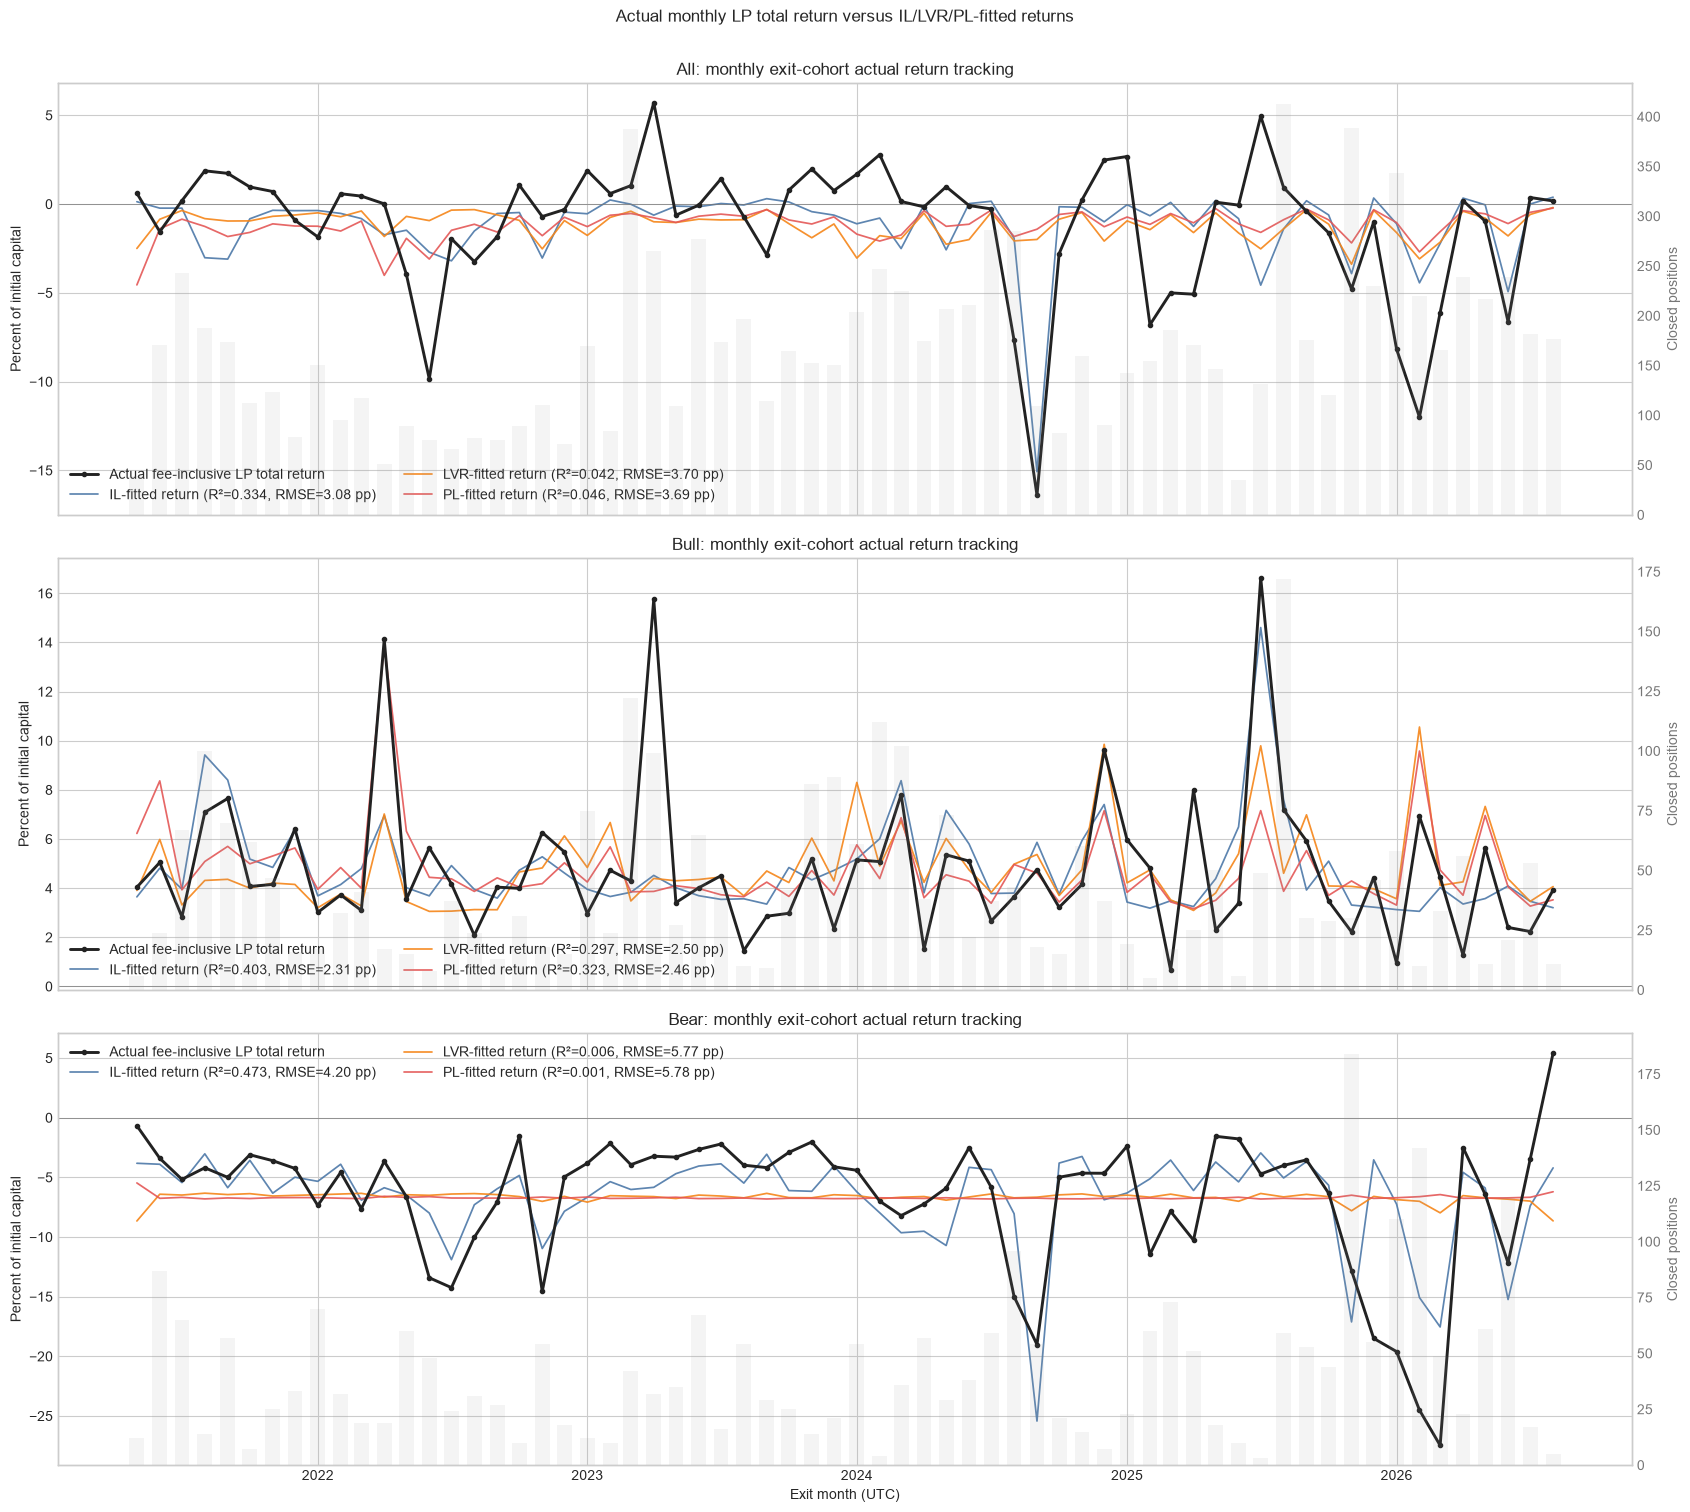

In [10]:
tracking_colors = {'IL': '#4C78A8', 'LVR': '#F58518', 'PL': '#E45756'}
fig, axes = plt.subplots(3, 1, figsize=(17, 15), sharex=True)
for axis, sample in zip(axes, ('All', 'Bull', 'Bear')):
    part = monthly_tracking_fitted.loc[
        monthly_tracking_fitted['sample'].eq(sample)
    ].sort_values('exit_month')
    axis.plot(
        part['exit_month'],
        part['actual_return_pct'],
        color='#222222',
        linewidth=2.1,
        marker='o',
        markersize=3.0,
        label='Actual fee-inclusive LP total return',
        zorder=5,
    )
    for label in ('IL', 'LVR', 'PL'):
        score = tracking_scores.loc[
            tracking_scores['sample'].eq(sample)
            & tracking_scores['metric'].eq(label)
        ].iloc[0]
        axis.plot(
            part['exit_month'],
            part[f'{label.lower()}_fitted_return_pct'],
            color=tracking_colors[label],
            linewidth=1.25,
            alpha=0.9,
            label=(
                f'{label}-fitted return '
                f'(R²={score.r_squared:.3f}, RMSE={score.rmse_pct_points:.2f} pp)'
            ),
        )
    axis.axhline(0.0, color='#777777', linewidth=0.7, alpha=0.7)
    axis.set(
        title=f'{sample}: monthly exit-cohort actual return tracking',
        ylabel='Percent of initial capital',
    )
    axis.legend(loc='best', ncol=2)
    count_axis = axis.twinx()
    count_axis.bar(
        part['exit_month'],
        part['position_count'],
        width=20,
        color='#999999',
        alpha=0.10,
    )
    count_axis.set_ylabel('Closed positions', color='#777777')
    count_axis.tick_params(axis='y', colors='#777777')
    count_axis.grid(False)
axes[-1].set_xlabel('Exit month (UTC)')
fig.suptitle(
    'Actual monthly LP total return versus IL/LVR/PL-fitted returns',
    y=1.005,
)
fig.tight_layout()
fig.savefig(
    FIGURE_ROOT / 'monthly_actual_return_tracking.png',
    dpi=180,
    bbox_inches='tight',
)
plt.show()


### 6.1 해석 범위

- 각 점은 해당 달에 청산된 position의 initial-capital-weighted 결과이며, 계속 보유되는 investable portfolio의 월별 return이 아니다.
- fitted line은 각 위험지표를 intercept와 slope로 실제 return 단위에 옮긴 단순 OLS 적합값이다. 원래 IL·LVR·PL의 경제적 정의나 크기가 동일하다는 뜻이 아니다.
- Bull/Bear는 calendar regime이 아니라 position별 entry-to-exit ETH return의 상·하위 25%다. 같은 달에 Bull과 Bear position이 동시에 청산될 수 있다.
- IL은 실제 LP return과 회계적으로 직접 연결되므로 높은 R²를 곧바로 더 우수한 이론적 위험지표라는 결론으로 해석하지 않는다.
- 비교 결과는 동기간 사후 설명 관계다. 실시간 선택이나 미래 return 예측의 근거로 사용하지 않는다.
- 실제 LP 총수익률은 관측된 realized fee를 포함하고 gas를 제외한다. IL·LVR·PL은 fee와 gas를 모두 제외한다.
